## **Predicting Disease Spread: EDA**

In [1]:
import sys
import os
import matplotlib.pyplot as plt
import pandas as pd

sys.path.append(os.path.abspath(".."))
from src.data_setup import load_data, split_cities
from src.visualization import (
    missing_data_percentage_by_city,
    weekly_cases_by_year,
    distribution_plots,
    weekly_cases,
    pairplot,
    plot_heatmap,
    plot_correlation_with_total_cases,
    train_vs_test_distribution,
    train_vs_test_features,
    visualize_comparision,
    visualize_histogram_labels
)

### **Objective**

The objective of the task is to predict number of cases (total_cases) for each city, year, week of year. We aim to result with as low as possible metric MAE.

### **Data description** ###
#### **City and date indicators** ####
- ```city``` - City abbreviations: sj for San Juan and iq for Iquitos
- ```week_start_date``` - Date given in yyyy-mm-dd format
#### **NOAA's GHCN daily climate data weather station measurements** ####
- ```station_max_temp_c``` - Maximum temperature
- ```station_min_temp_c``` - Minimum temperature
- ```station_avg_temp_c``` - Average temperature
- ```station_precip_mm``` - Total precipitation
- ```station_diur_temp_rng_c``` - Diurnal temperature range
#### **PERSIANN satellite precipitation measurements (0.25x0.25 degree scale)** ####
- ```precipitation_amt_mm``` - Total precipitation
#### **NOAA's NCEP Climate Forecast System Reanalysis measurements (0.5x0.5 degree scale)** ####
- ```reanalysis_sat_precip_amt_mm``` - Total precipitation
- ```reanalysis_dew_point_temp_k``` - Mean dew point temperature
- ```reanalysis_air_temp_k``` - Mean air temperature
- ```reanalysis_relative_humidity_percent``` - Mean relative humidity
- ```reanalysis_specific_humidity_g_per_kg``` - Mean specific humidity
- ```reanalysis_precip_amt_kg_per_m2``` - Total precipitation
- ```reanalysis_max_air_temp_k``` - Maximum air temperature
- ```reanalysis_min_air_temp_k``` - Minimum air temperature
- ```reanalysis_avg_temp_k``` - Average air temperature
- ```reanalysis_tdtr_k``` - Diurnal temperature range
#### **Satellite vegetation - Normalized difference vegetation index (NDVI) - NOAA's CDR Normalized Difference Vegetation Index (0.5x0.5 degree scale)** ####
- ```ndvi_se``` - Pixel southeast of city centroid
- ```ndvi_sw``` - Pixel southwest of city centroid
- ```ndvi_ne``` - Pixel northeast of city centroid
- ```ndvi_nw``` - Pixel northwest of city centroid

### **Geographical Information** ###

#### **Iquitos** ####
Peru (Latin America, Amazon Jungle, by the Amazon River) <br>
population: 491 000 (2023)

<img src="photos/peru_map.png" alt="Peru map" width="400"/>


Source: [ResearchGate](https://www.researchgate.net/publication/280031052)


#### **San Juan** ####
Puerto Rico (the Carribean, shores of the Atlantic Ocean) <br>
pupulation: 338 661 (2023)

<img src="photos/puerto_rico_map.jpg" alt="Puerto Rico map" width="400"/>

Source: (©iStock.com/PeterHermesFurian)

Both cities are located in tropical regions, which means that they have a tropical climate. The climate is characterized by high temperatures and high humidity. 

In [2]:
features_train, labels_train = load_data(train=True)

In [3]:
sj_features_train, iq_features_train = split_cities(features_train)
sj_labels_train, iq_labels_train = split_cities(labels_train)

In [4]:
features_train.describe()

,ndvi_ne,ndvi_nw,ndvi_se,ndvi_sw,precipitation_amt_mm,reanalysis_air_temp_k,reanalysis_avg_temp_k,reanalysis_dew_point_temp_k,reanalysis_max_air_temp_k,reanalysis_min_air_temp_k,reanalysis_precip_amt_kg_per_m2,reanalysis_relative_humidity_percent,reanalysis_sat_precip_amt_mm,reanalysis_specific_humidity_g_per_kg,reanalysis_tdtr_k,station_avg_temp_c,station_diur_temp_rng_c,station_max_temp_c,station_min_temp_c,station_precip_mm
count,1262.000000,1404.000000,1434.000000,1434.000000,1443.000000,1446.000000,1446.000000,1446.000000,1446.000000,1446.000000,1446.000000,1446.000000,1443.000000,1446.000000,1446.000000,1413.000000,1413.000000,1436.000000,1442.000000,1434.000000
mean,0.142294,0.130553,0.203783,0.202305,45.760388,298.701852,299.225578,295.246356,303.427109,295.719156,40.151819,82.161959,45.760388,16.746427,4.903754,27.185783,8.059328,32.452437,22.102150,39.326360
std,0.140531,0.119999,0.073860,0.083903,43.715537,1.362420,1.261715,1.527810,3.234601,2.565364,43.434399,7.153897,43.715537,1.542494,3.546445,1.292347,2.128568,1.959318,1.574066,47.455314
min,-0.406250,-0.456100,-0.015533,-0.063457,0.000000,294.635714,294.892857,289.642857,297.800000,286.900000,0.000000,57.787143,0.000000,11.715714,1.357143,21.400000,4.528571,26.700000,14.700000,0.000000
25%,0.044950,0.049217,0.155087,0.144209,9.800000,297.658929,298.257143,294.118929,301.000000,293.900000,13.055000,77.177143,9.800000,15.557143,2.328571,26.300000,6.514286,31.100000,21.100000,8.700000
50%,0.128817,0.121429,0.196050,0.189450,38.340000,298.646429,299.289286,295.640714,302.400000,296.200000,27.245000,80.301429,38.340000,17.087143,2.857143,27.414286,7.300000,32.800000,22.200000,23.850000
75%,0.248483,0.216600,0.248846,0.246982,70.235000,299.833571,300.207143,296.460000,305.500000,297.900000,52.200000,86.357857,70.235000,17.978214,7.625000,28.157143,9.566667,33.900000,23.300000,53.900000
max,0.508357,0.454429,0.538314,0.546017,390.600000,302.200000,302.928571,298.450000,314.000000,299.900000,570.500000,98.610000,390.600000,20.461429,16.028571,30.800000,15.800000,42.200000,25.600000,543.300000


### **Missing data** ###

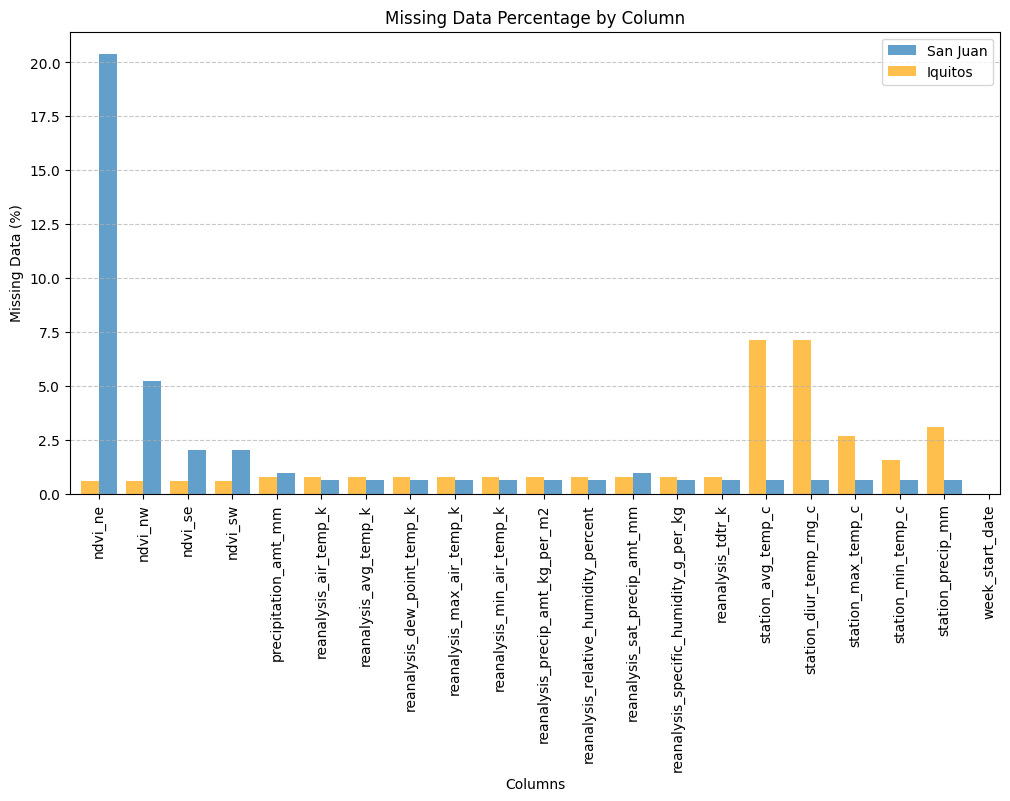

In [5]:
missing_data_percentage_by_city(sj_features_train, iq_features_train)

### **Total cases over time** ###


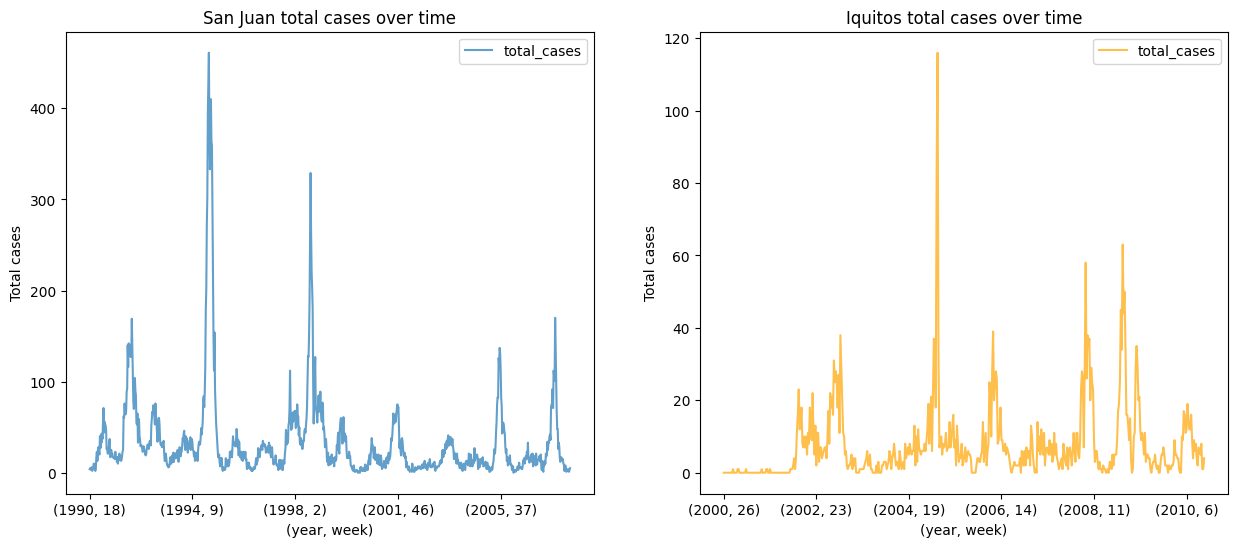

In [6]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 6), sharey=False)
sj_labels_train.plot(
    alpha=0.7,
    ax=axes[0],
    title="San Juan total cases over time",
    xlabel="(year, week)",
    ylabel="Total cases",
)
iq_labels_train.plot(
    alpha=0.7,
    color="orange",
    ax=axes[1],
    title="Iquitos total cases over time",
    xlabel="(year, week)",
    ylabel="Total cases",
)

plt.show()

It is worth denoting that for different cities there are different time frames of increasing number of cases.

### **Weekly cases** ###

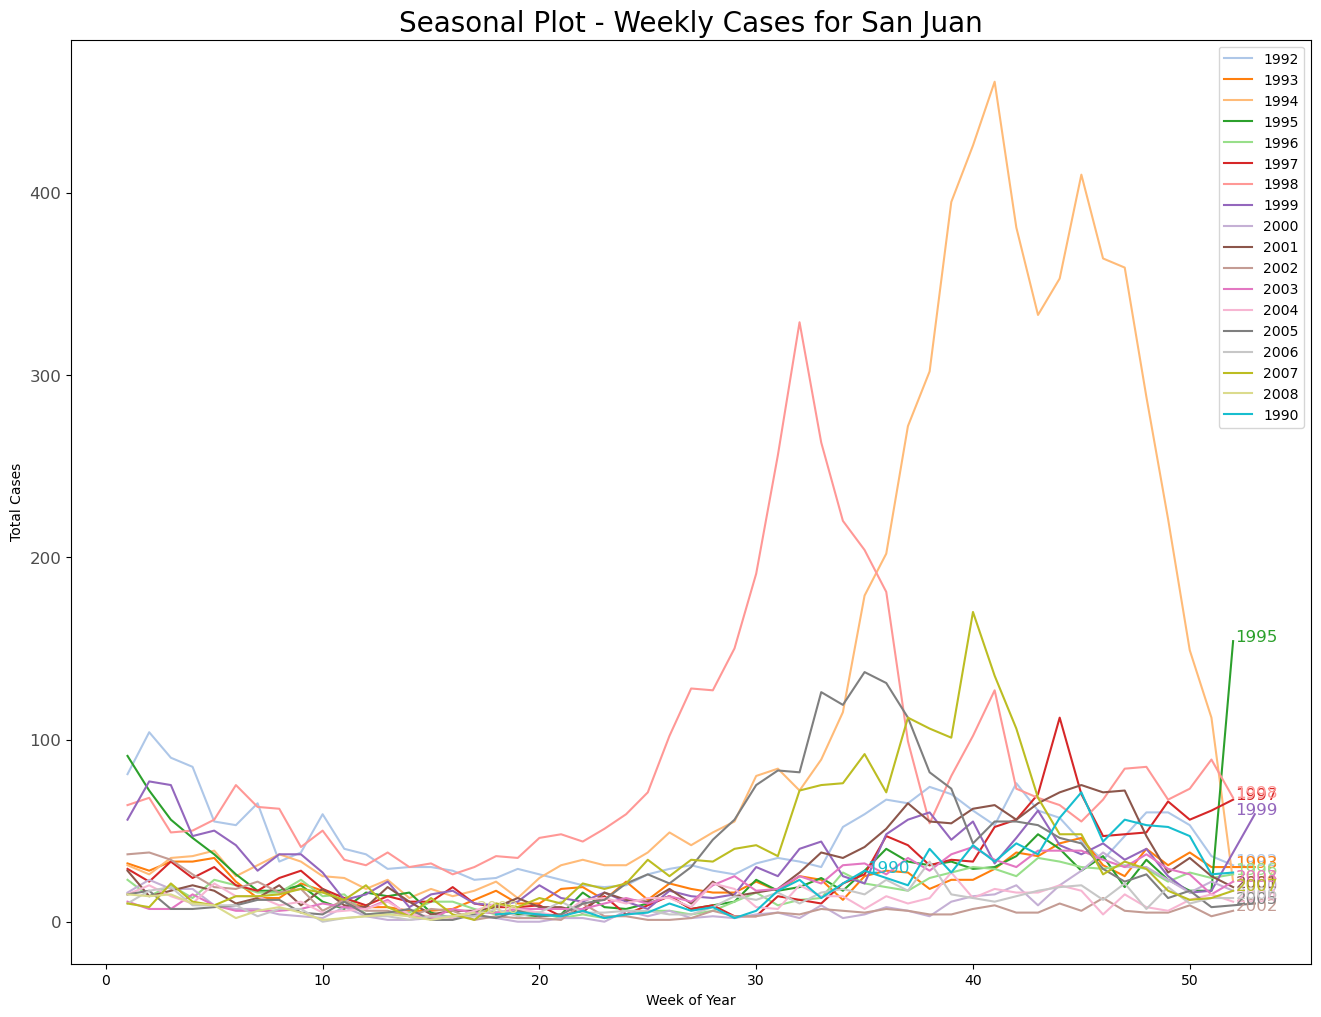

In [4]:
weekly_cases_by_year(sj_labels_train, city="San Juan")

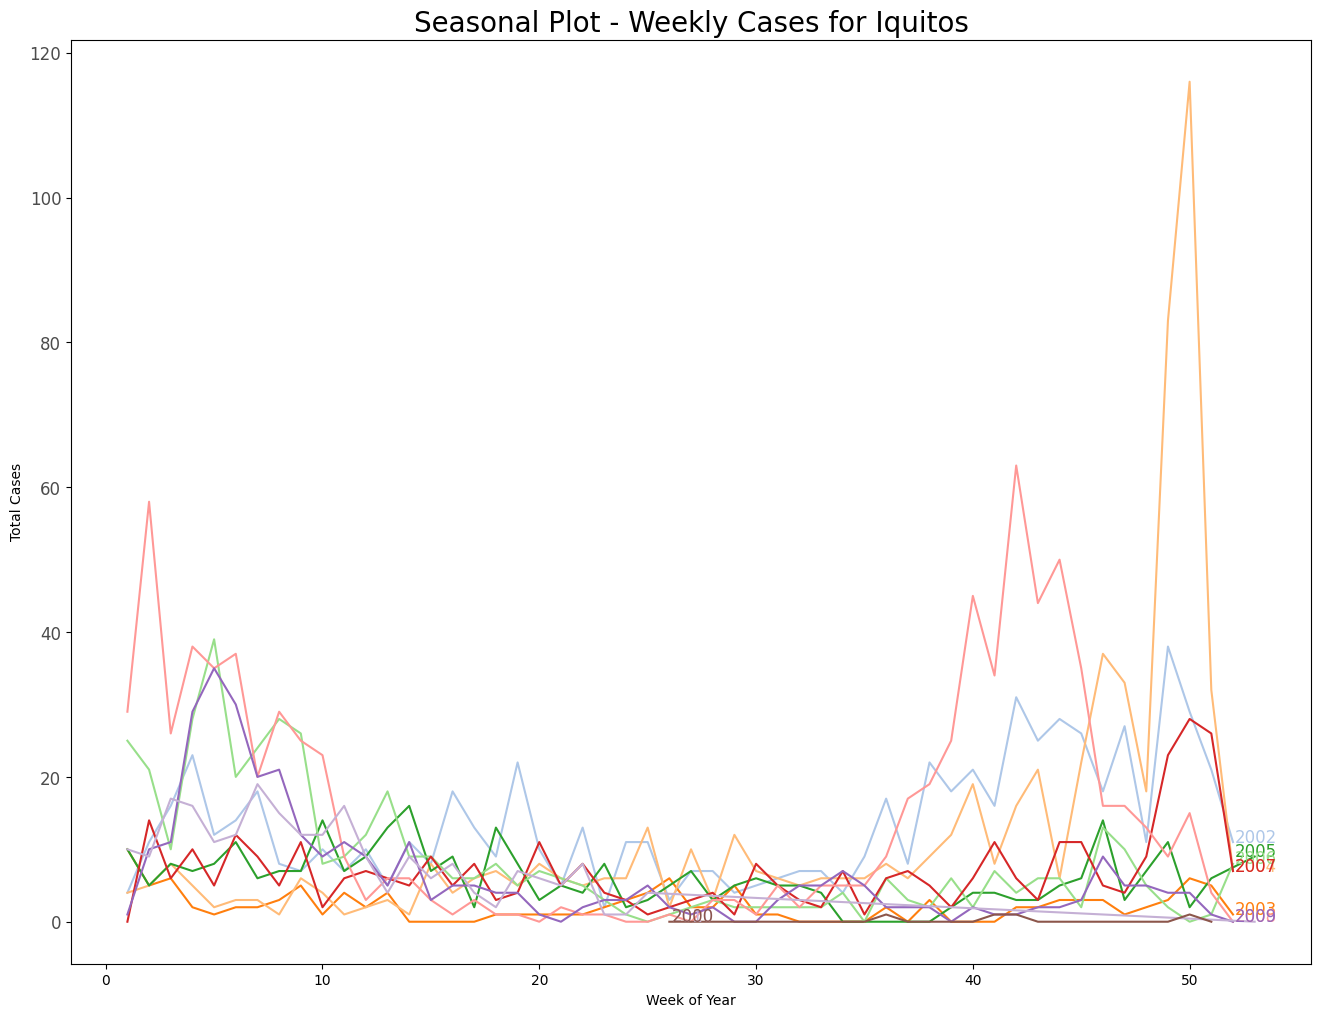

In [8]:
weekly_cases_by_year(iq_labels_train, city="Iquitos")

### **Features comparision** ###

From the plots above, we can see that each year experienced an epidemic peak in cases. Below, we compare various statistics between the whole year and the pre-peak period.

Komentarz na brudno: tutaj mozna posprawdzac rozne cechy wpisujac w to_compare i stestowac rozne okresy przed peakiem wpisujac period(ile tygodni przed peakiem) jako argument.

narazie pokazuje te ktore (jakos) ciekawie wyszly, mozna tu jeszcze poszukac czegos fajnego.

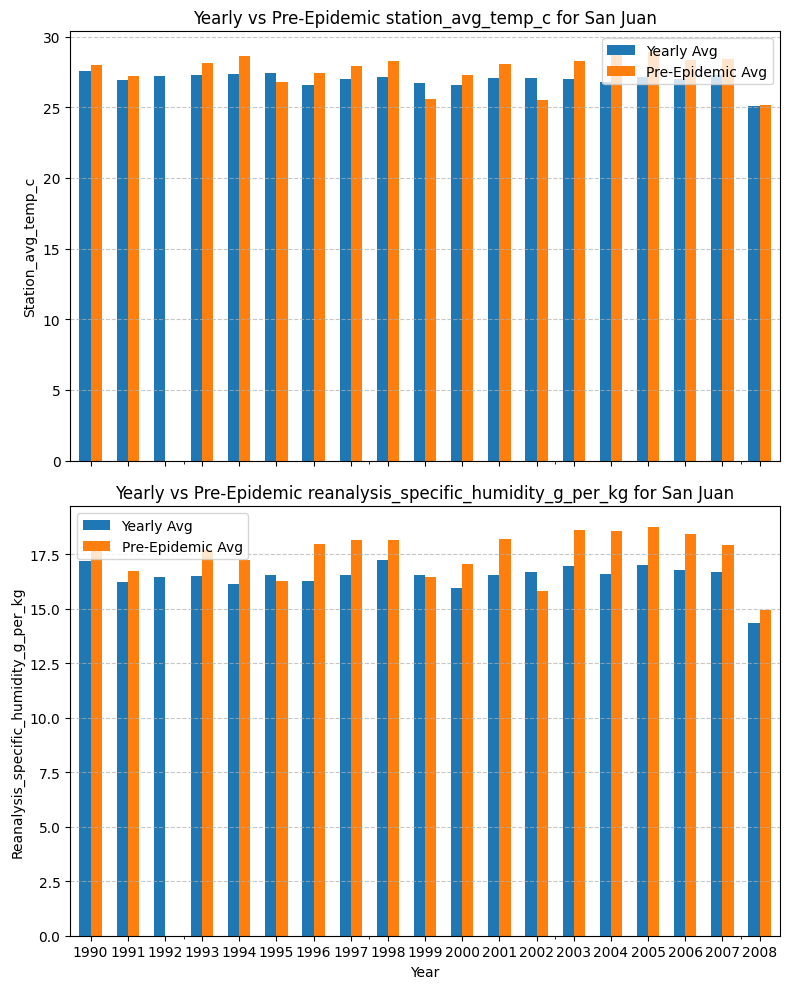

In [9]:
to_compare = ["station_avg_temp_c", "reanalysis_specific_humidity_g_per_kg"]

visualize_comparision(sj_features_train,
                      sj_labels_train,
                      period=6,
                      to_compare=to_compare,
                      city="San Juan")

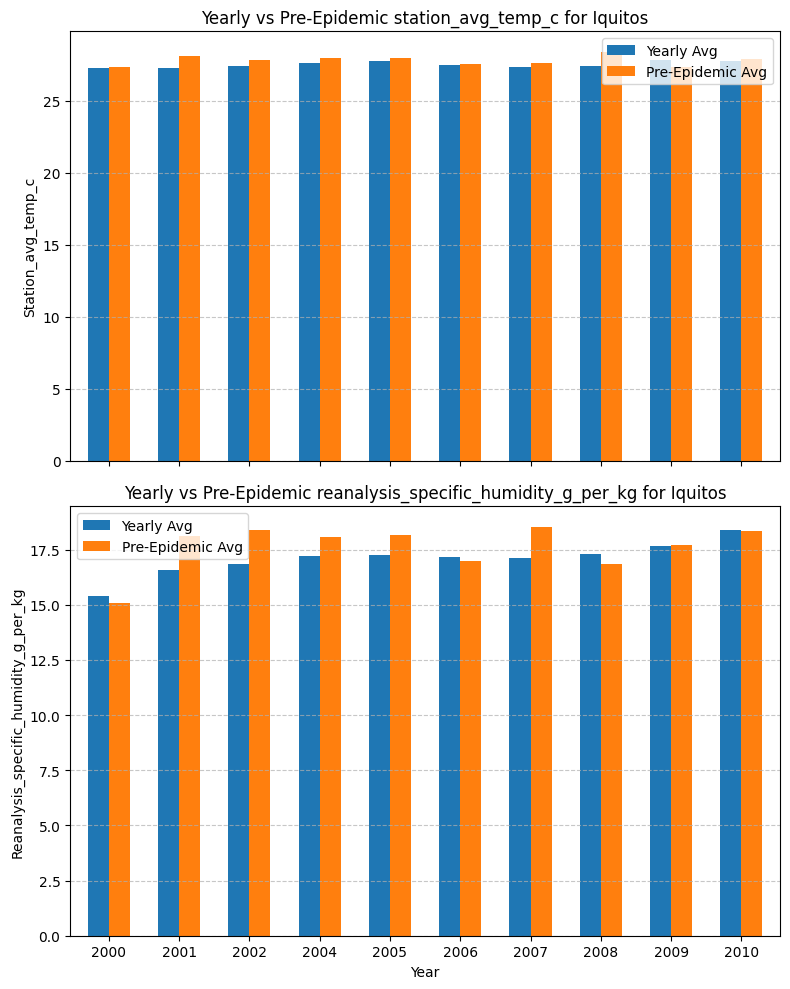

In [10]:
visualize_comparision(iq_features_train,
                      iq_labels_train,
                      period=6,
                      to_compare=to_compare,
                      city="Iquitos")

From the plots above, we can see that the disease typically spreads more during hotter and more humid periods.

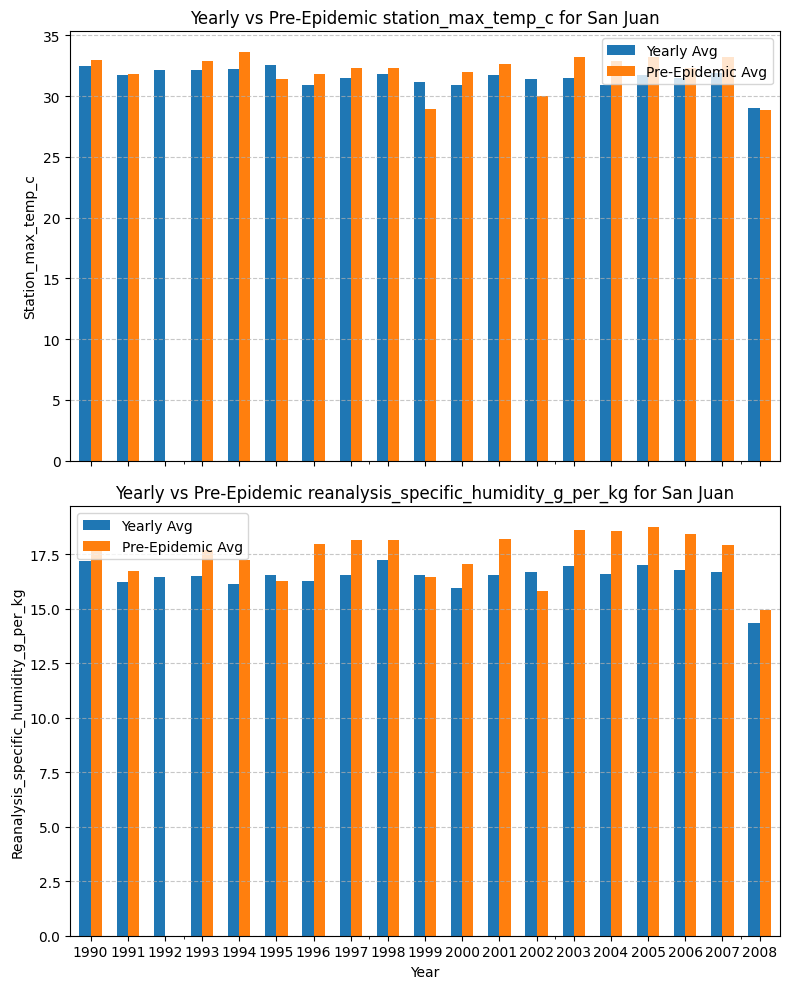

In [11]:
to_compare = ["station_max_temp_c", "reanalysis_specific_humidity_g_per_kg"]

visualize_comparision(sj_features_train,
                      sj_labels_train,
                      period=6,
                      to_compare=to_compare,
                      city="San Juan")

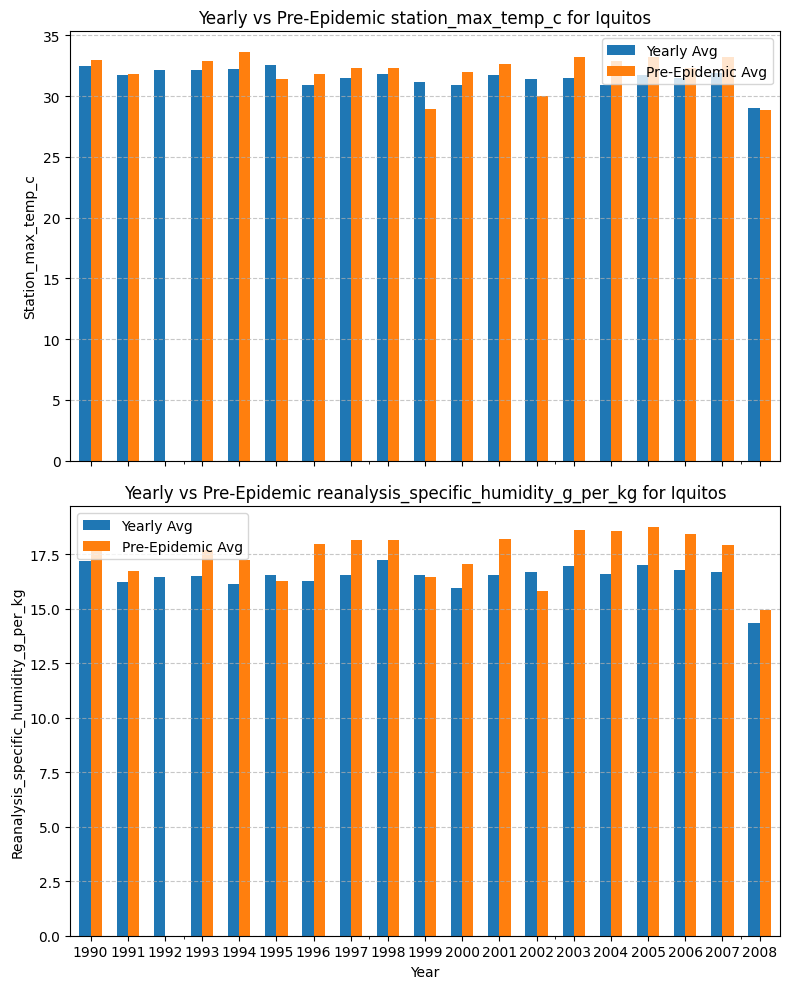

In [12]:
to_compare = ["station_max_temp_c", "reanalysis_specific_humidity_g_per_kg"]

visualize_comparision(sj_features_train,
                      sj_labels_train,
                      period=6,
                      to_compare=to_compare,
                      city="Iquitos")

station_max_temp_c has similiar behaviour to ave temperature - no surprise here.

### **Correlation beteween features and total cases** ###

#### Spearman

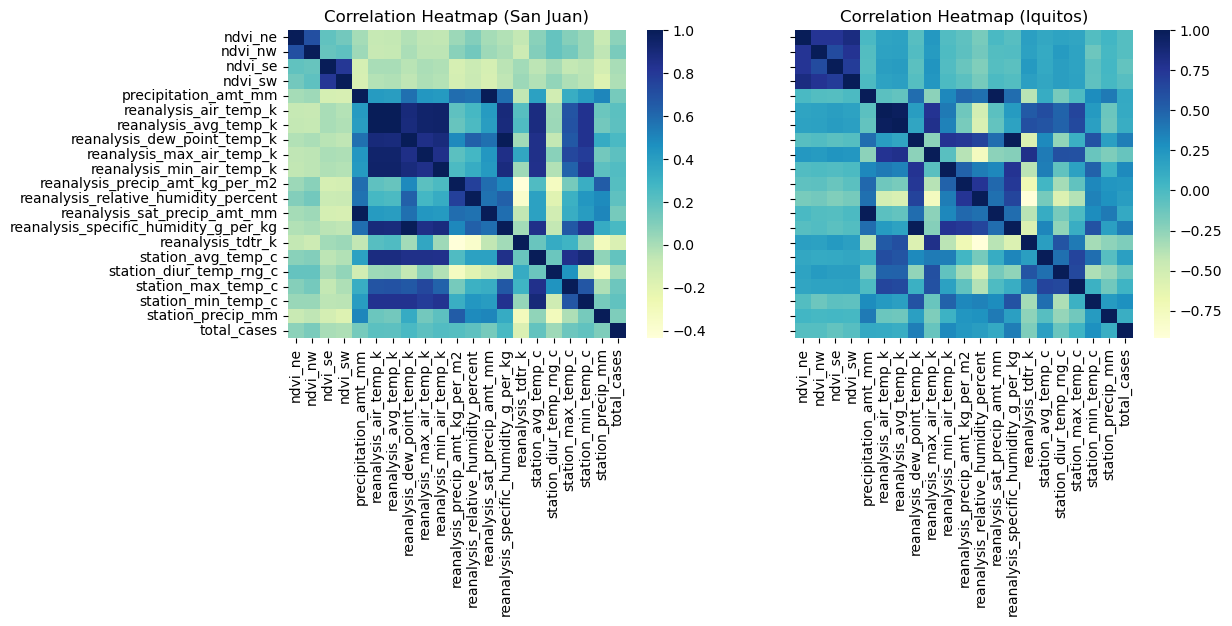

In [5]:
sj_data_train = sj_features_train.copy()
sj_data_train["total_cases"] = sj_labels_train.total_cases
iq_data_train = iq_features_train.copy()
iq_data_train["total_cases"] = iq_labels_train.total_cases

plot_heatmap(sj_data_train, iq_data_train, spearman=True)

#### Pearson

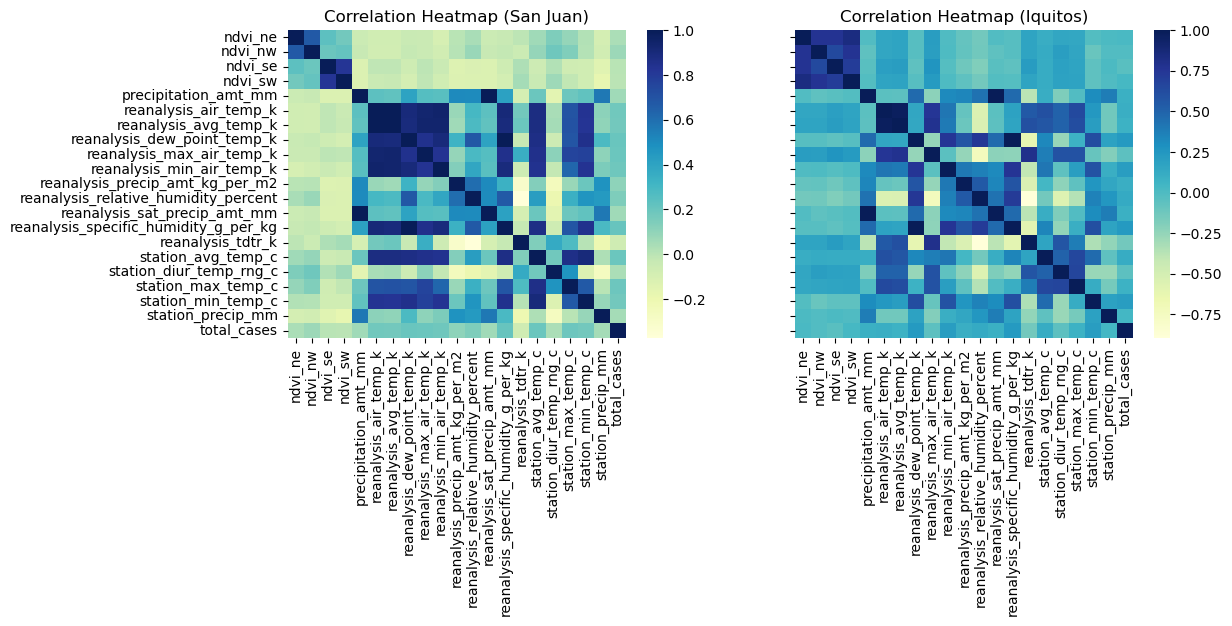

In [7]:
sj_data_train = sj_features_train.copy()
sj_data_train["total_cases"] = sj_labels_train.total_cases
iq_data_train = iq_features_train.copy()
iq_data_train["total_cases"] = iq_labels_train.total_cases

plot_heatmap(sj_data_train, iq_data_train, spearman=False)

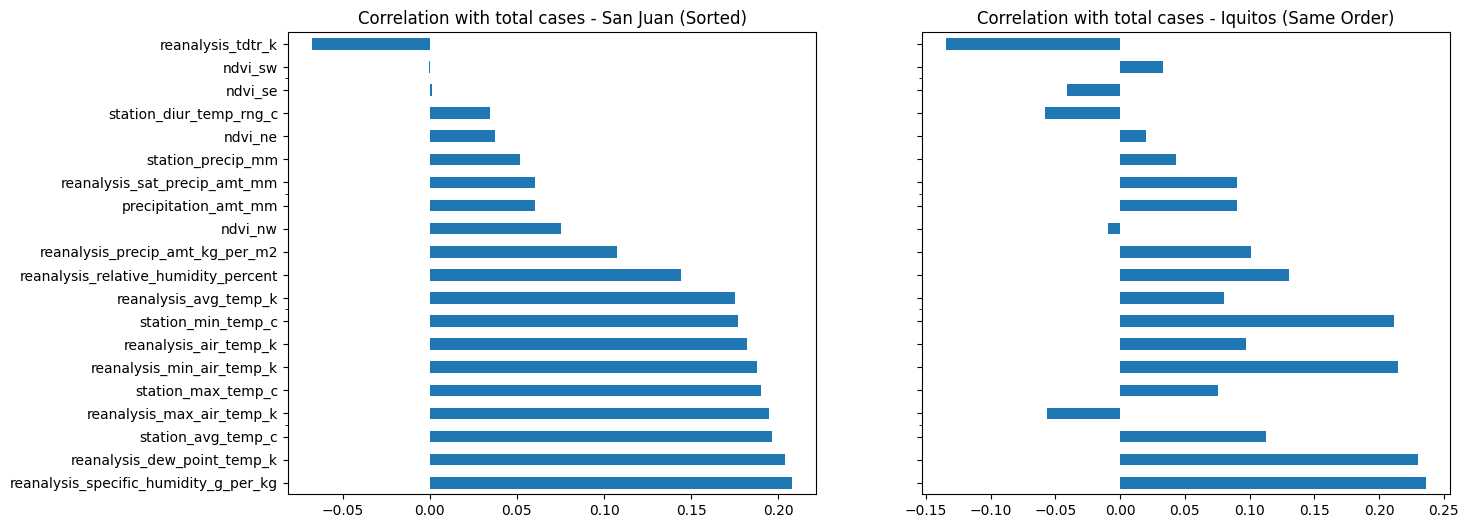

In [14]:
plot_correlation_with_total_cases(sj_data_train, iq_data_train)

Correlation between features and total cases depends on the city. This means that we will have to build a model for each city.

### **Features distribution** ###

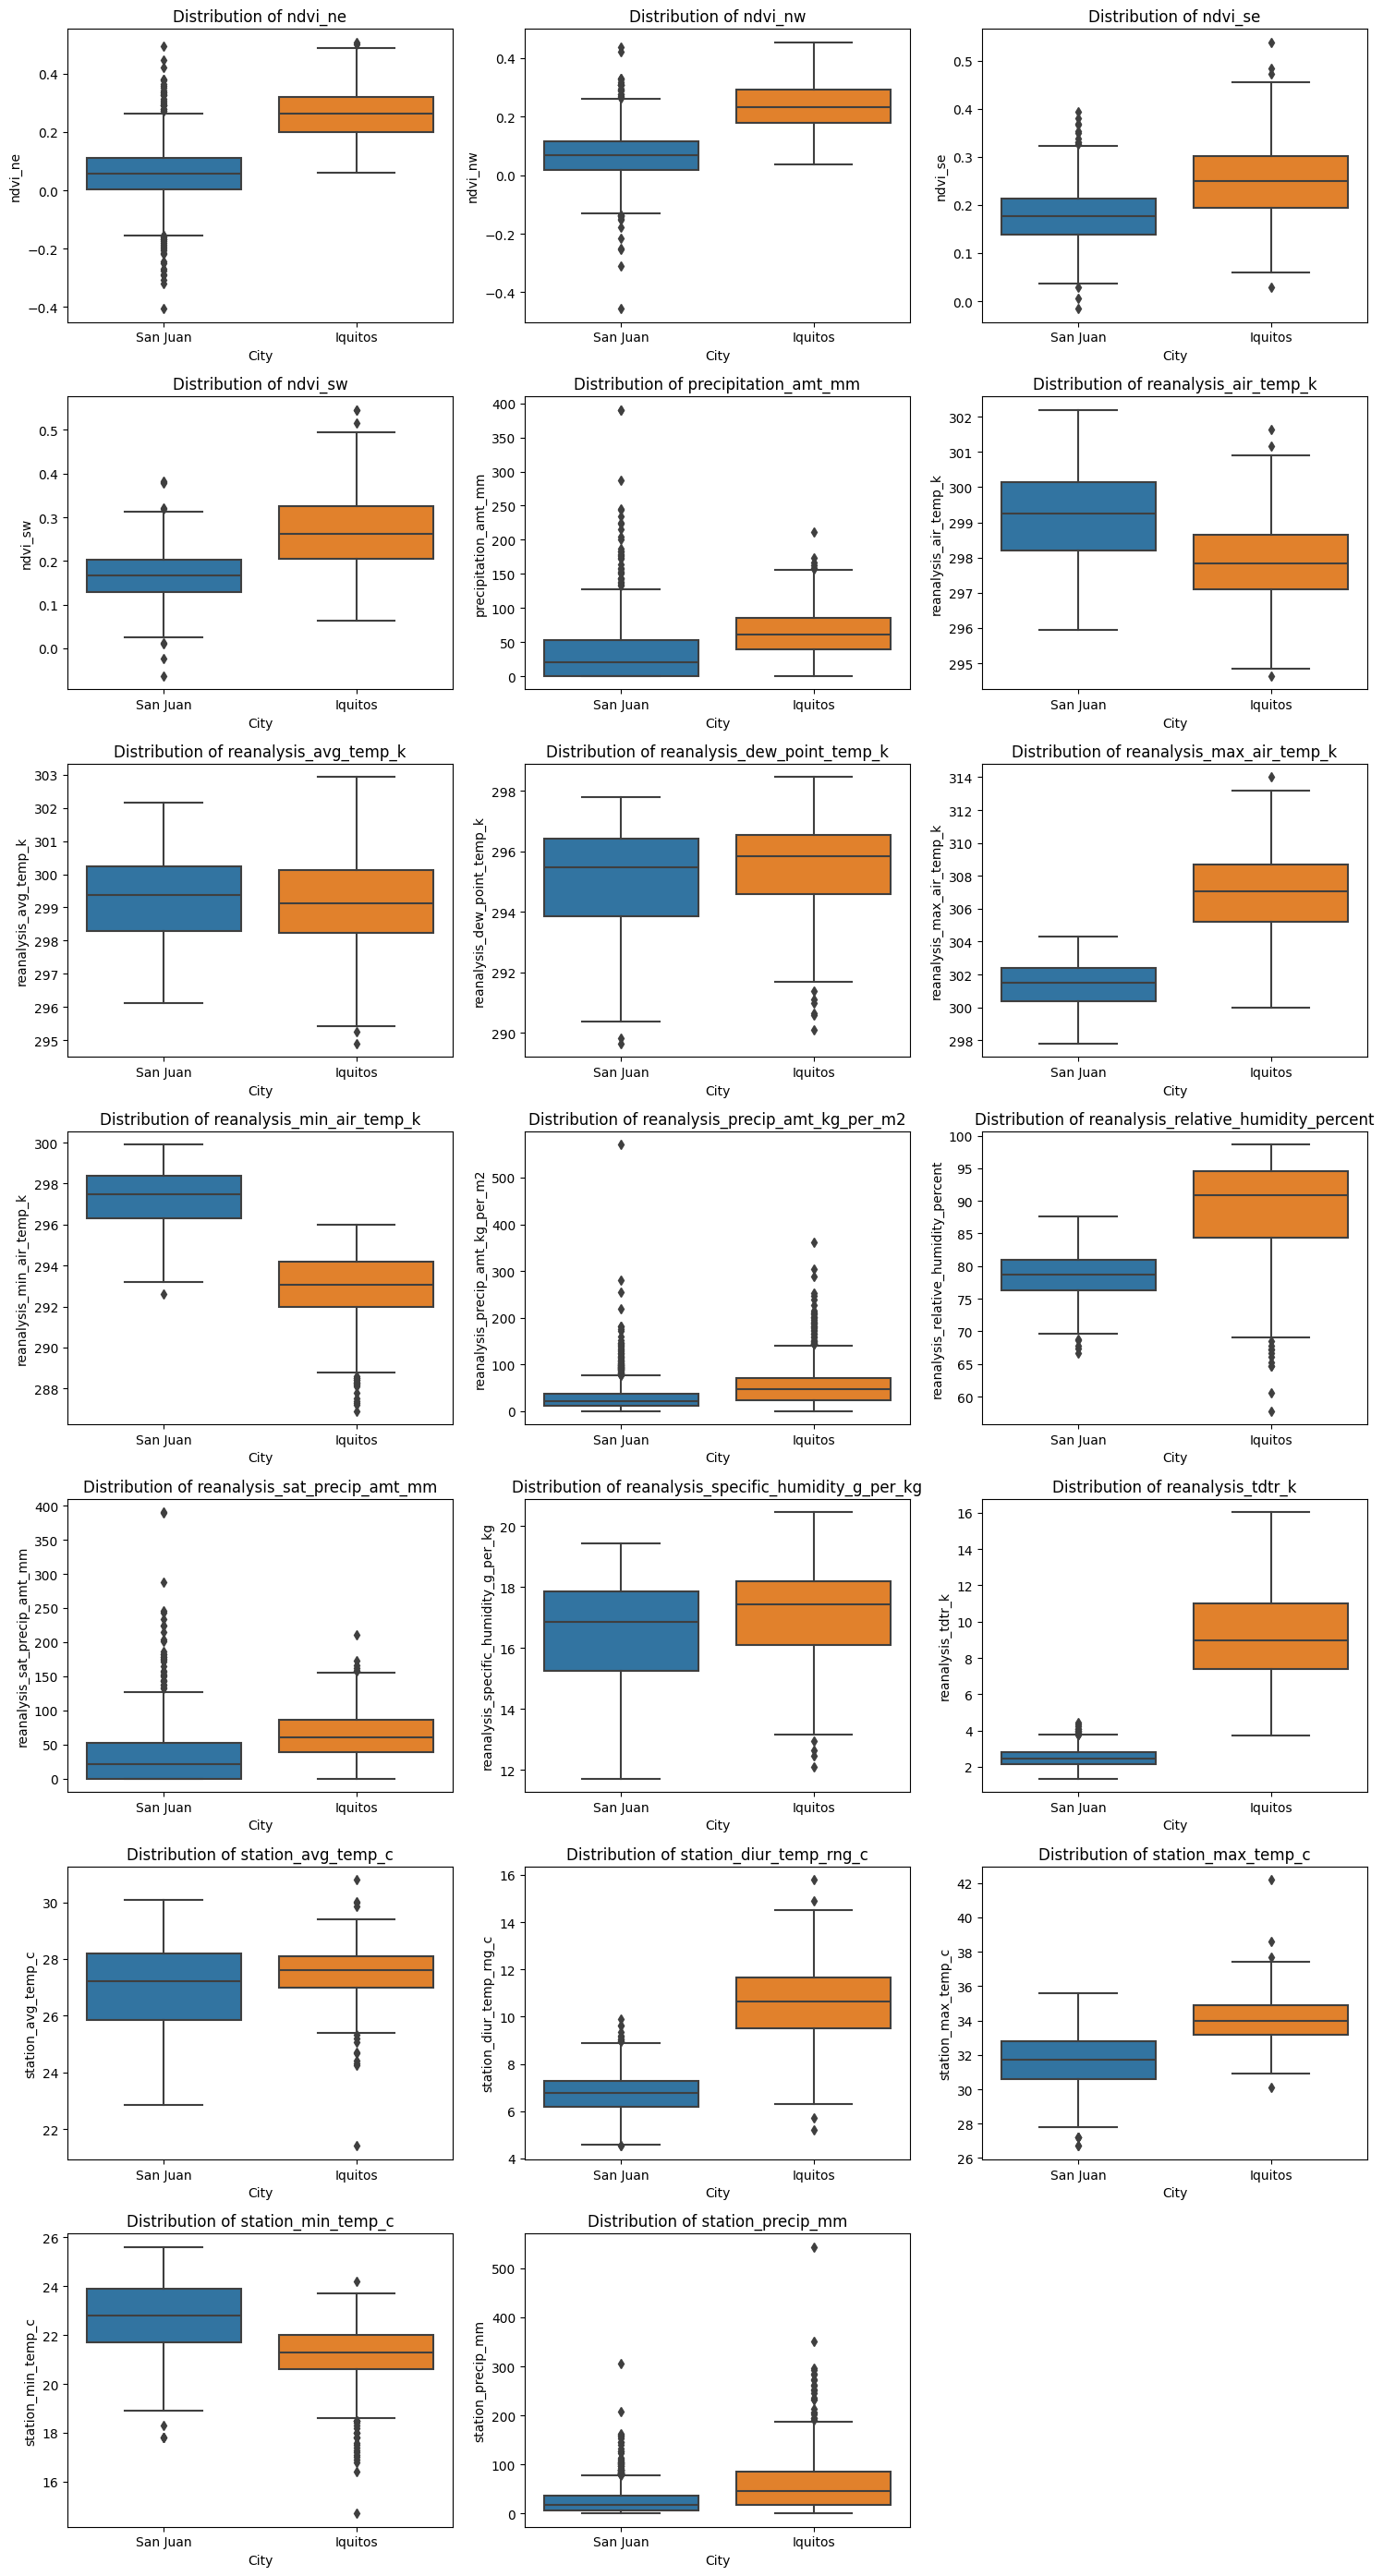

In [15]:
distribution_plots(
    sj_features_train.drop(features_train.columns[0], axis=1),
    iq_features_train.drop(features_train.columns[0], axis=1),
)

### **Pairplot** ###

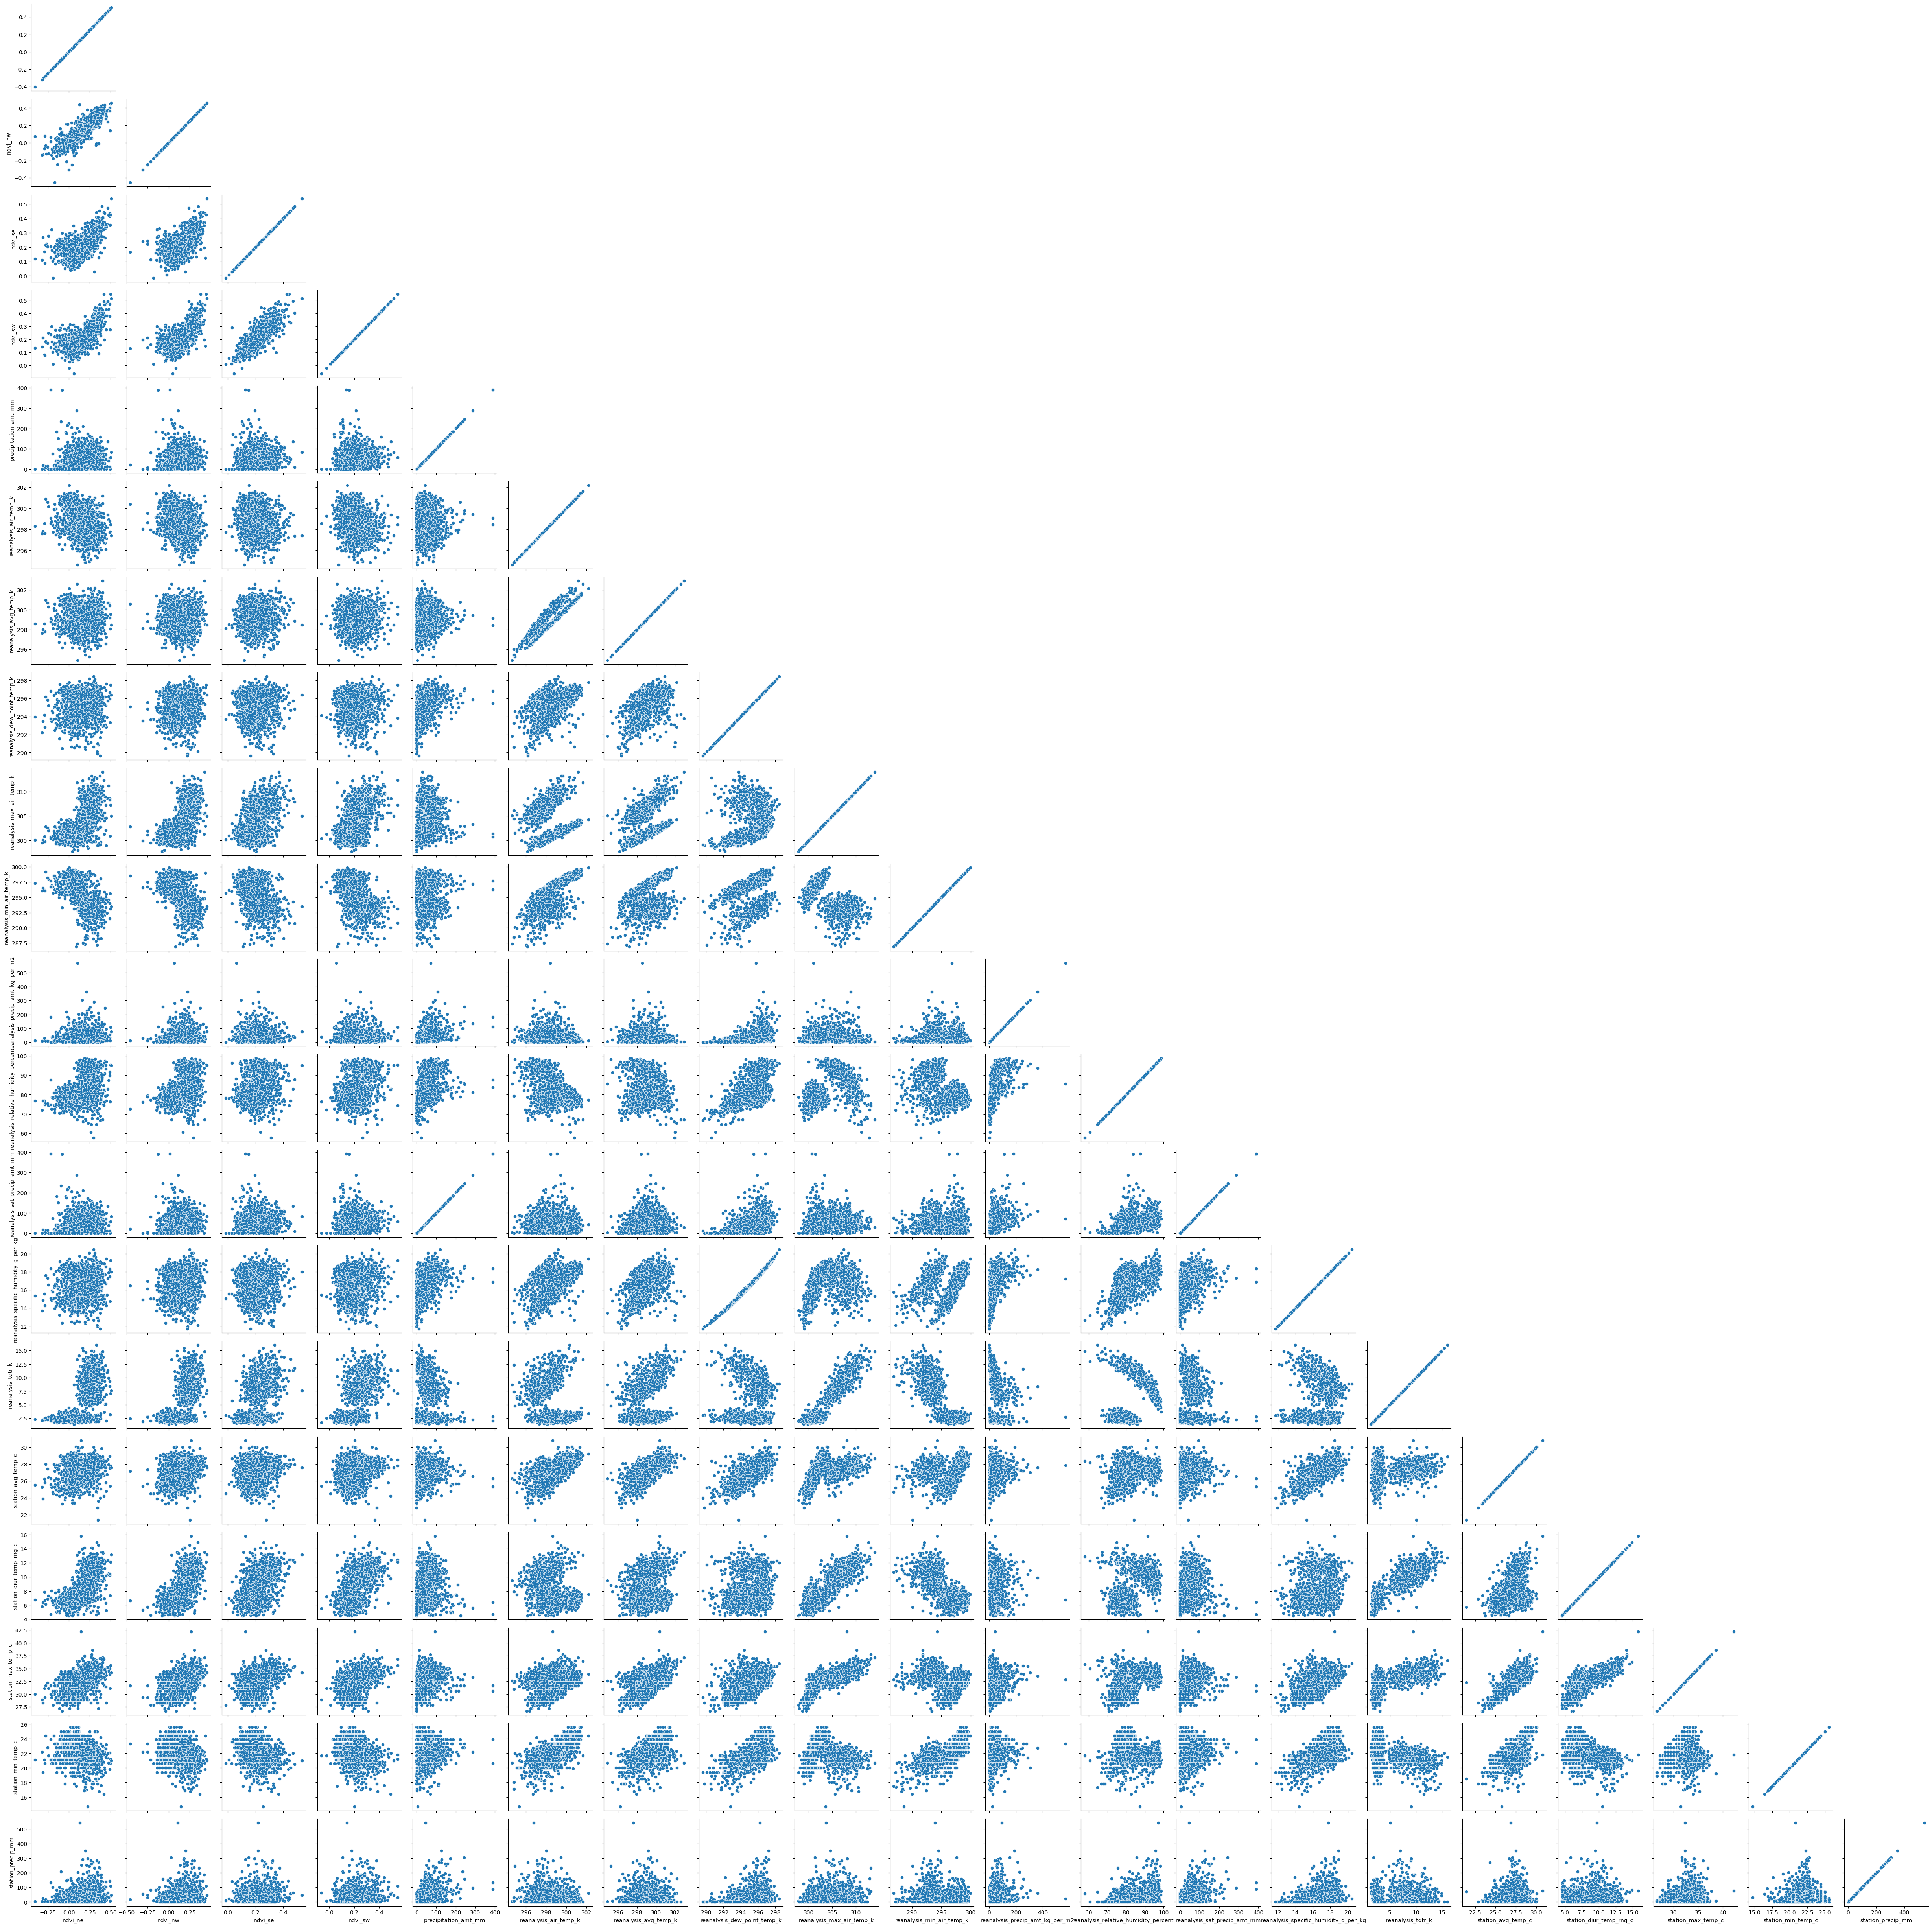

In [16]:
pairplot(features_train)

### **Weekly cases** ###

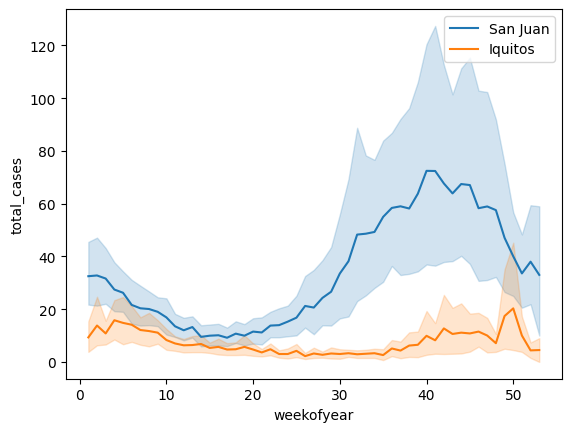

In [17]:
weekly_cases(data=sj_labels_train, city="San Juan")
weekly_cases(data=iq_labels_train, city="Iquitos")

In [18]:
features_test, labels_test = load_data(train=False)

In [19]:
features_train_copy = features_train.copy()
features_train_copy["dataset"] = "Train"
features_test_copy = features_test.copy()
features_test_copy["dataset"] = "Test"
concatenated_data = pd.concat([features_train_copy, features_test_copy])

### **What are we going to predict?** ###

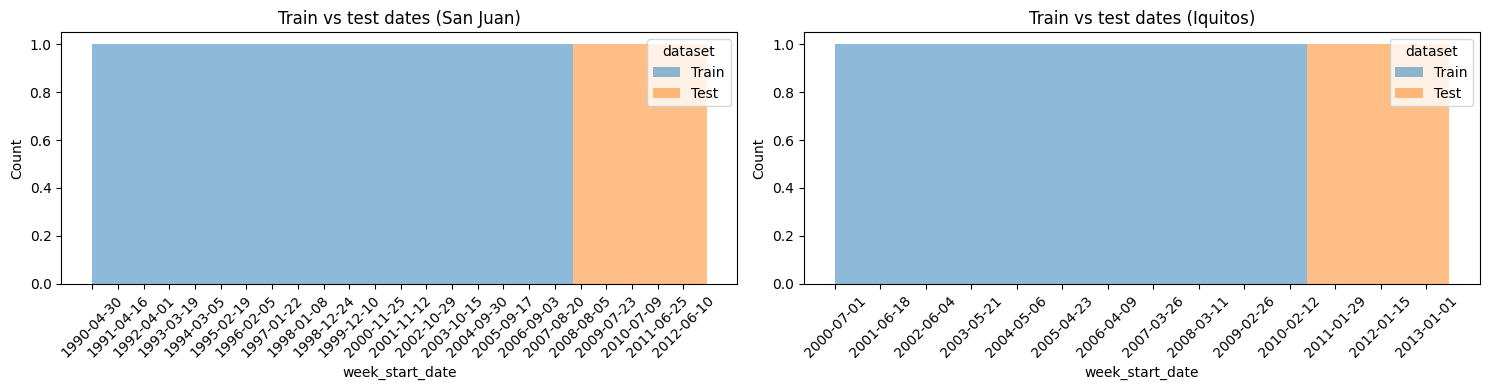

In [20]:
concatenated_data_sj = concatenated_data.loc["sj"]
concatenated_data_iq = concatenated_data.loc["iq"]
train_vs_test_distribution(concatenated_data_sj, concatenated_data_iq)

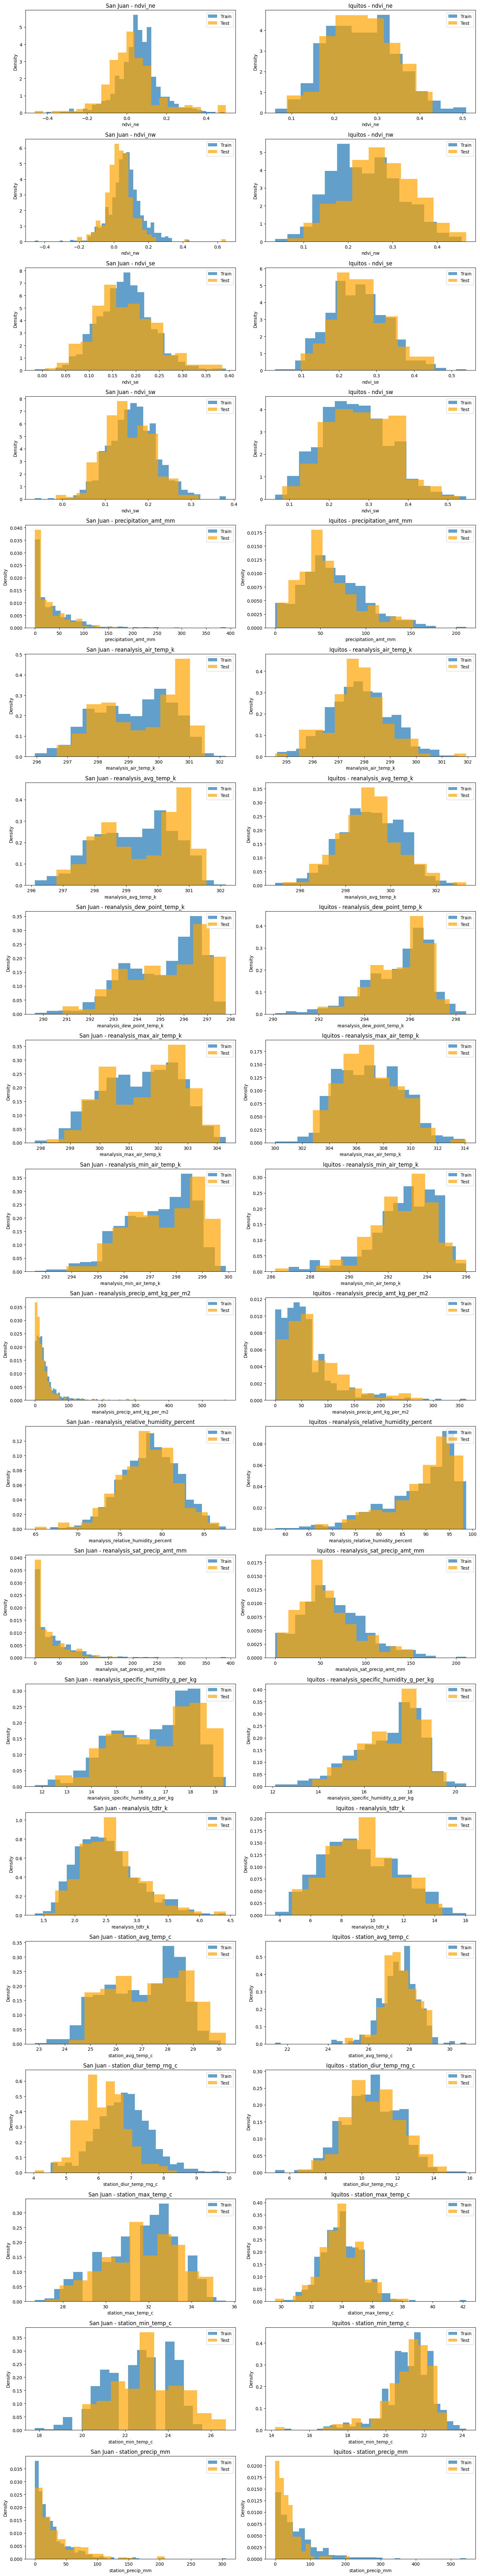

In [21]:
concatenated_data_sj = concatenated_data.loc["sj"].drop(columns=["week_start_date"])
concatenated_data_iq = concatenated_data.loc["iq"].drop(columns=["week_start_date"])
train_vs_test_features(concatenated_data_sj, concatenated_data_iq)

The distribution of features in train and test data is similar, so the fact that the split is not random should not affect the model.

### **Labels distribution**

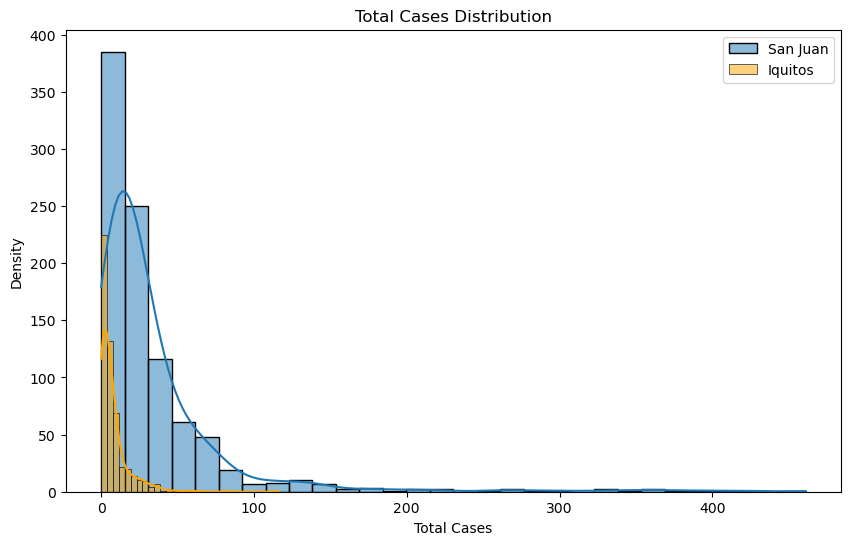

In [4]:
visualize_histogram_labels(labels=labels_train)

### **Conculsions** ###
1. Each city has different features that are correlated with the total cases.
2. Each city requires each own feature engineering (data imputation, feature selection, feature scaling, etc.).
3. For FE part, it should be discussed to sum all ndvi_xx (vegetation indexes)
4. We have to build a model for each city.
5. We have to predict the total cases for the future (with respect to the training data).